# Import Libraries & Load Data

In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import userdata

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_API_TOKEN")

In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle datasets list -s ecommerce

ref                                                             title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
saurabhshahane/ecommerce-text-classification                    Ecommerce Text Classification                         8236809  2023-10-09 14:01:29.687000          16121        114                1  
uzmaakhtar/ecommerce-sales-data                                 Ecommerce _Sales_Data                                   42375  2026-02-10 10:55:50.750000           1618         68                1  
cclark/product-item-data                                        eCommerce Item Data                                    140589  2016-08-18 00:32:54.173000          18480        214        0.7058824  
mmoha

In [ ]:
!kaggle datasets download -d olistbr/brazilian-ecommerce
!unzip -q brazilian-ecommerce.zip

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
100% 42.6M/42.6M [00:02<00:00, 15.4MB/s]



In [ ]:
for file in os.listdir():
  if file.endswith('.csv'):
    print(file)

product_category_name_translation.csv
olist_order_reviews_dataset.csv
olist_sellers_dataset.csv
olist_geolocation_dataset.csv
olist_customers_dataset.csv
olist_order_items_dataset.csv
olist_products_dataset.csv
olist_orders_dataset.csv
olist_order_payments_dataset.csv


# Data Understanding and cleaning
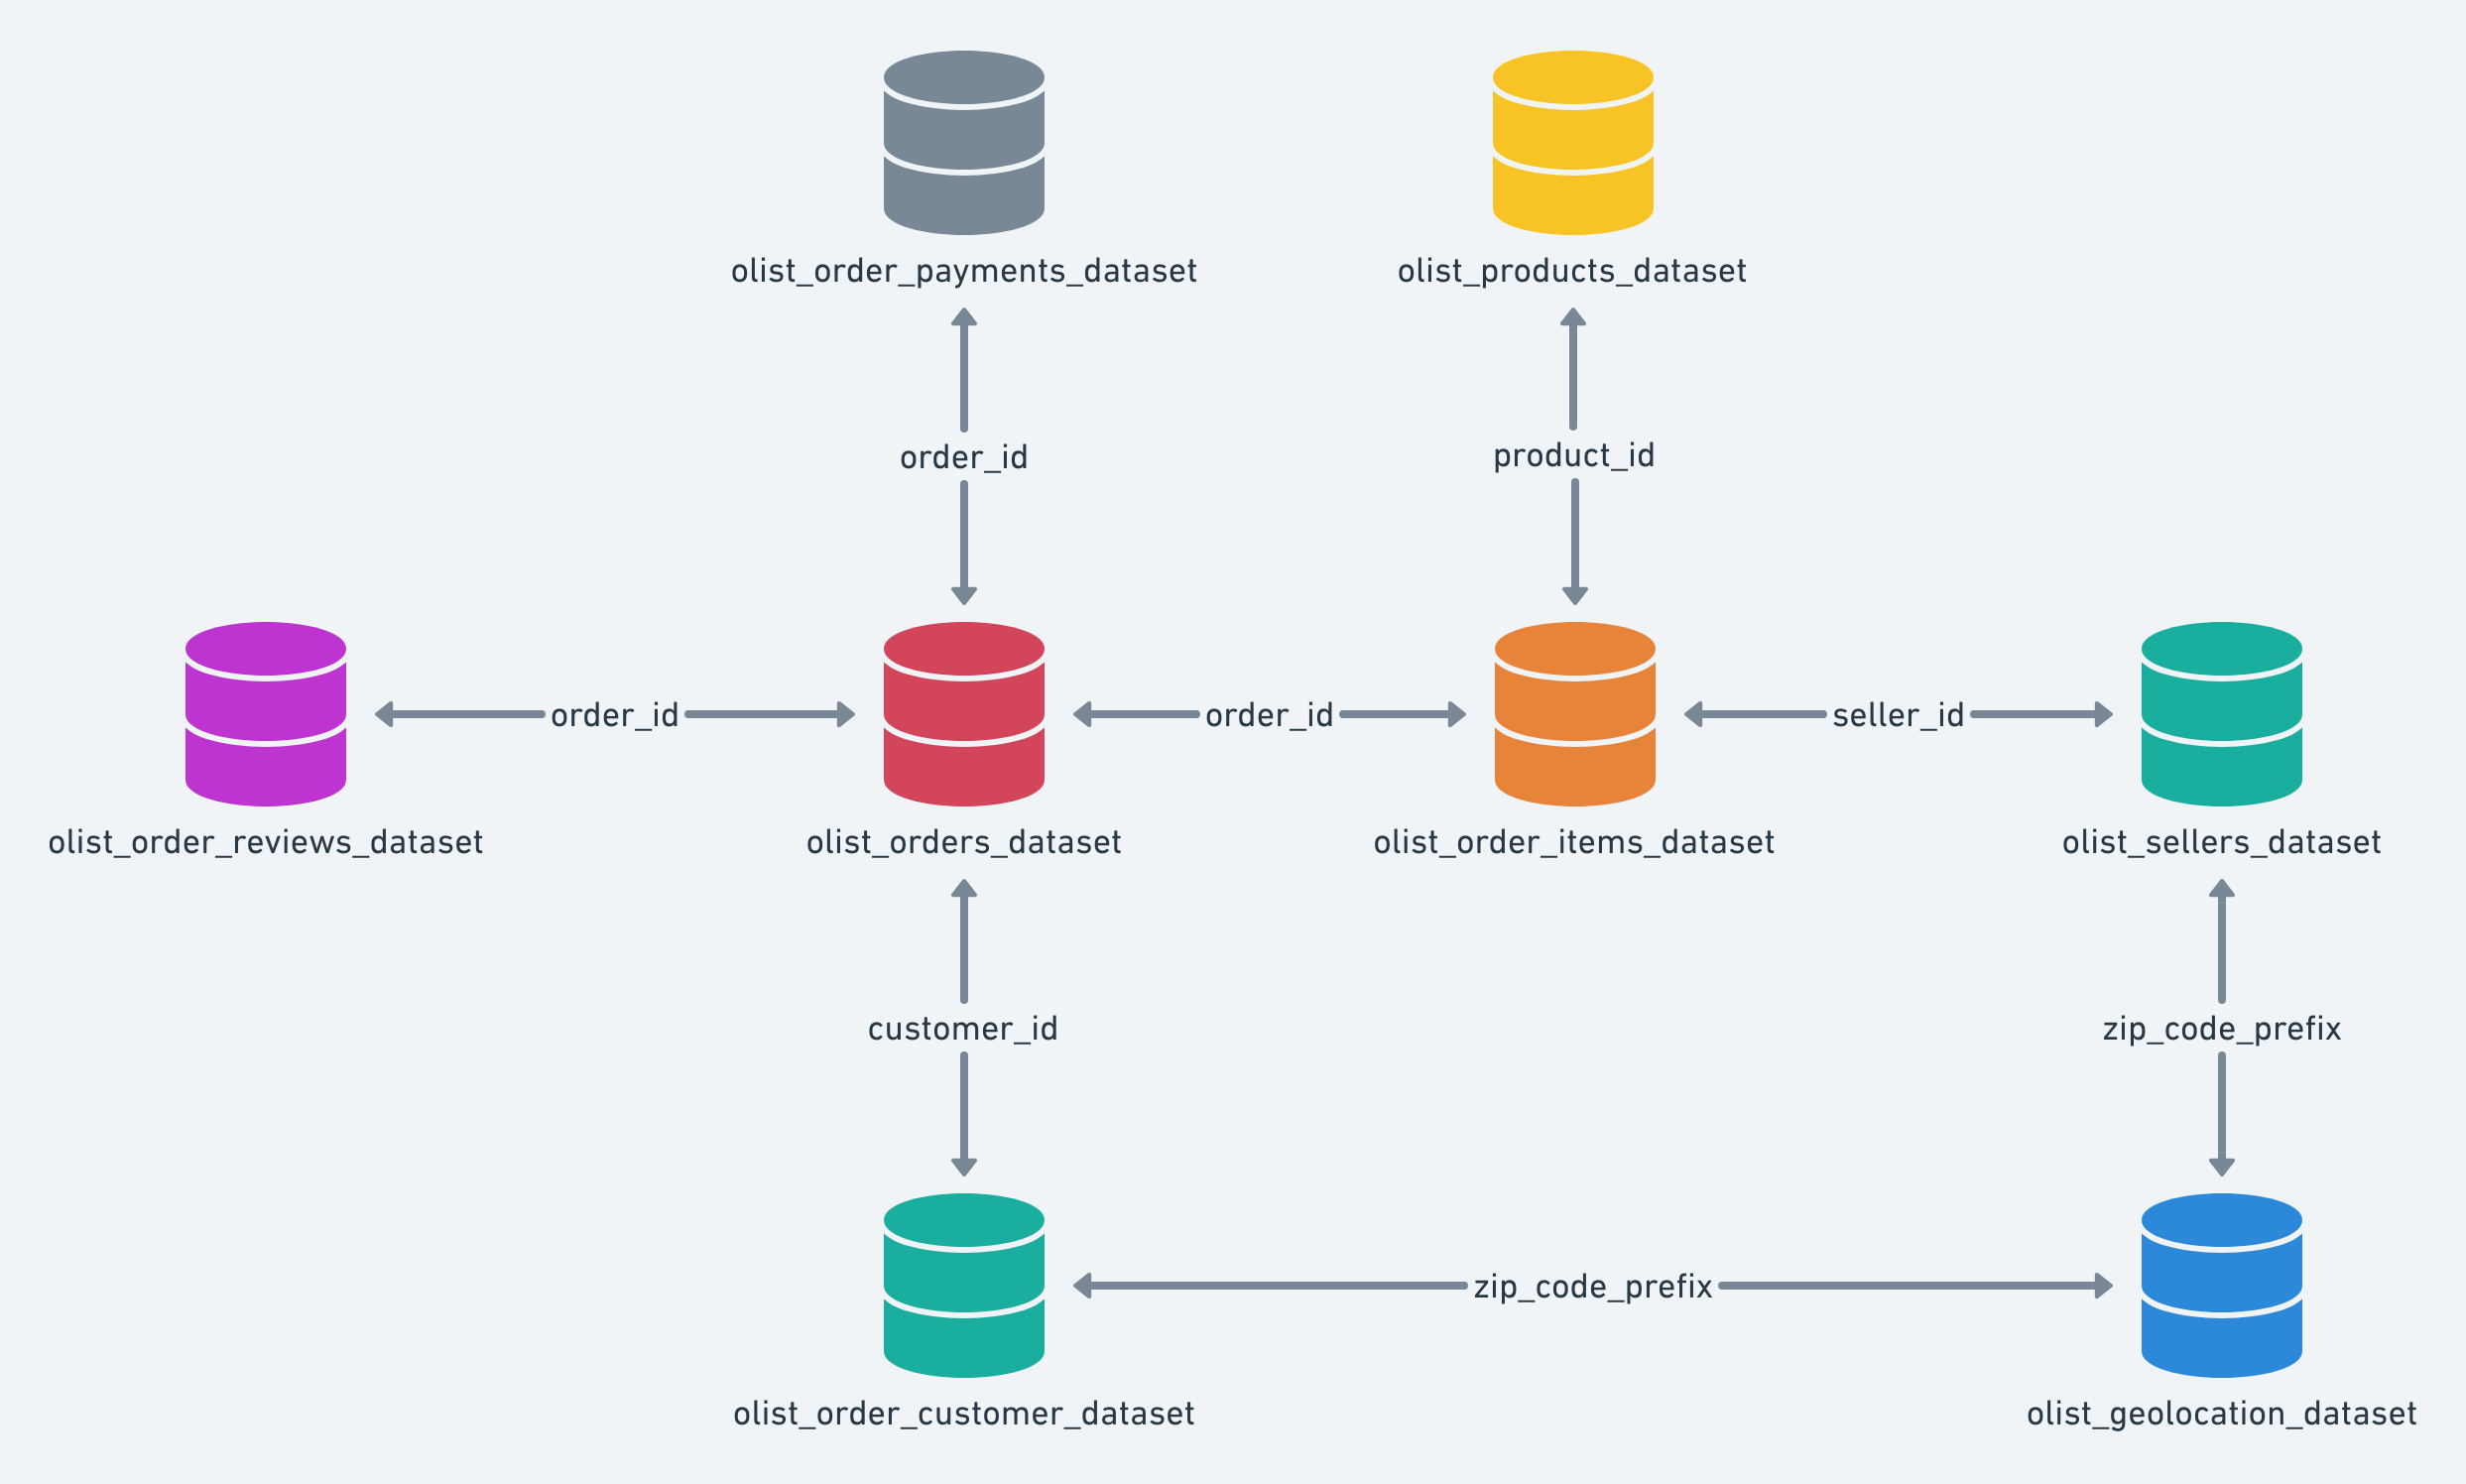

In [ ]:
category_translation = pd.read_csv('product_category_name_translation.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
geoloaction = pd.read_csv('olist_geolocation_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')


# Olist E-commerce Dataset Description
### 1. `orders` Table (Central Registry)
This is the core table that connects all other data points.
- **order_id**: Unique identifier for each order.
- **customer_id**: Key to the customer table (unique per order).
- **order_status**: Status of the order (delivered, shipped, canceled, etc.).
- **order_purchase_timestamp**: Timestamp of when the purchase was made.
- **order_approved_at**: Timestamp of payment approval.
- **order_delivered_carrier_date**: Timestamp of when the order was handed over to the logistics partner.
- **order_delivered_customer_date**: Actual delivery date to the customer.
- **order_estimated_delivery_date**: The estimated delivery date informed to the customer at purchase.

### 2. `order_items` Table (Itemized Details)
- **order_id**: Unique order identifier.
- **order_item_id**: Sequential number identifying the number of items within the same order.
- **product_id**: Unique product identifier.
- **seller_id**: Unique seller identifier.
- **shipping_limit_date**: The deadline for the seller to ship the product to the carrier.
- **price**: Item price (Unit: BRL - Brazilian Real).
- **freight_value**: Shipping cost (Unit: BRL).

### 3. `products` Table (Product Metadata)
- **product_id**: Unique product identifier.
- **product_category_name**: Category name in Portuguese.
- **product_name_lenght**: Number of characters in the product name.
- **product_description_lenght**: Number of characters in the product description.
- **product_photos_qty**: Number of published photos for the product.
- **product_weight_g**: Product weight (Unit: Grams).
- **product_length_cm, product_height_cm, product_width_cm**: Product dimensions (Unit: Centimeters).

### 4. `payments` Table (Transaction Details)
- **order_id**: Unique order identifier.
- **payment_sequential**: Sequence of payments (in case of multiple methods).
- **payment_type**: Method used (credit_card, boleto, voucher, debit_card).
- **payment_installments**: Number of installments chosen by the customer.
- **payment_value**: Total transaction amount (Unit: BRL).

### 5. `customers` Table (Customer Demographics)
- **customer_id**: Key used to link to the orders table.
- **customer_unique_id**: Unique identifier for a customer (allows tracking repeat purchases).
- **customer_zip_code_prefix**: First five digits of customer zip code.
- **customer_city**: Customer city name.
- **customer_state**: Customer state.

### 6. `reviews` Table (Feedback Data)
- **review_id**: Unique review identifier.
- **order_id**: Unique order identifier.
- **review_score**: Rating ranging from 1 to 5.
- **review_comment_title**: Title of the review comment.
- **review_comment_message**: Content of the review comment.
- **review_creation_date**: Date the satisfaction survey was sent.
- **review_answer_timestamp**: Date and time of the actual response.

### 7. `sellers` Table (Merchant Data)
- **seller_id**: Unique seller identifier.
- **seller_zip_code_prefix**: Seller's zip code.
- **seller_city**: Seller's city.
- **seller_state**: Seller's state.

### 8. Supplemental Tables
- **category_translation**: Maps `product_category_name` from Portuguese to English.
- **geolocation**: Contains geographic coordinates (lat/lng) associated with zip code prefixes for mapping and spatial analysis.
```

In [ ]:
#usage table
dataset = {
    "orders": orders,
    "customers": customers,
    "order_items": order_items,
    "payments": payments,
    "products": products,
    "reviews": reviews,
    "category_translation": category_translation,
    "geoloaction": geoloaction,
    "sellers": sellers
}

for name, df in dataset.items():

    print("="*80)
    print(f"{name.upper()}")

    print("\nShape:")
    print(df.shape)

    print("\nInfo:")
    df.info()

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    print("\nSample:")
    display(df.head())

ORDERS

Shape:
(99441, 8)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrie

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


CUSTOMERS

Shape:
(99441, 5)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

Missing Values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Duplicate Rows:
0

Sample:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


ORDER_ITEMS

Shape:
(112650, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB

Missing Values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Duplicate Rows:
0

Sample:


...

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


GEOLOACTION

Shape:
(1000163, 5)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB

Missing Values:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

Duplicate Rows:
261831

Sample:


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


SELLERS

Shape:
(3095, 4)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB

Missing Values:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Duplicate Rows:
0

Sample:


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


## Data Quality Summary

Based on the initial data understanding, here's a summary of potential data quality issues that need to be addressed:

### **customers**
- No immediate data quality issues identified (no missing values, no duplicates, appropriate data types).

### **orders**
- **Missing Values**: `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` have missing values. These will need to be handled, possibly by imputation, removal, or understanding their impact on analysis.
- **Data Type Conversion**: All timestamp columns are now converted to `datetime` objects.

### **order_items**
- **Data Type Conversion**: `shipping_limit_date` has been converted to `datetime`.
- No other immediate data quality issues identified.

### **payments**
- No immediate data quality issues identified (no missing values, no duplicates, appropriate data types).

### **products**
- **Missing Values**: Several columns (`product_category_name`, dimensions, etc.) had missing values which have now been imputed using median (numeric) or 'unknown' (categorical).

### **reviews**
- **Missing Values**: `review_comment_title` and `review_comment_message` have been filled with 'no comment'.
- **Data Type Conversion**: Timestamp columns have been converted to `datetime`.

### **sellers**
- No immediate data quality issues identified (no missing values, no duplicates).

### **category_translation**
- No immediate data quality issues identified (no missing values, no duplicates).

### **geoloaction**
- No missing values found.
- Note: High number of rows (1,000,163) which might require optimization if merged later.

##General Cleaning

### Converting Data Types for `orders` DataFrame

In [ ]:
print('Converting data types for orders dataframe...')
# Convert timestamp columns in 'orders' dataframe to datetime
for col in ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']:
    if col in orders.columns:
        orders[col] = pd.to_datetime(orders[col], errors='coerce')

print('\nOrders DataFrame Info after conversion:')
orders.info()
print('\nOrders DataFrame Sample after conversion:')
display(orders.head())

Converting data types for orders dataframe...

Orders DataFrame Info after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB

Orders DataFrame Sample after conversion:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


### Converting Data Types for `order_items` DataFrame

In [ ]:
print('Converting data types for order_items dataframe...')
# Convert 'shipping_limit_date' in 'order_items' dataframe to datetime
if 'shipping_limit_date' in order_items.columns:
    order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'], errors='coerce')

print('Order Items DataFrame Info after conversion:')
order_items.info()
print('Order Items DataFrame Sample after conversion:')
display(order_items.head())

Converting data types for order_items dataframe...
Order Items DataFrame Info after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB
Order Items DataFrame Sample after conversion:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


### Converting Data Types for `reviews` DataFrame

In [ ]:
print('Converting data types for reviews dataframe...')
# Convert timestamp columns in 'reviews' dataframe to datetime
for col in ['review_creation_date', 'review_answer_timestamp']:
    if col in reviews.columns:
        reviews[col] = pd.to_datetime(reviews[col], errors='coerce')

print('Reviews DataFrame Info after conversion:')
reviews.info()
print('Reviews DataFrame Sample after conversion:')
display(reviews.head())

Converting data types for reviews dataframe...
Reviews DataFrame Info after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB
Reviews DataFrame Sample after conversion:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


### Classifying Data Types for All DataFrames in `dataset`

In [ ]:
# Dictionary to store classified columns for each DataFrame
classified_columns_by_dataframe = {}

for name, df in dataset.items():
    numeric_cols = []
    category_cols = []
    datetime_cols = []

    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
        elif pd.api.types.is_datetime64_any_dtype(df[col]):
            datetime_cols.append(col)
        else:
            category_cols.append(col)

    classified_columns_by_dataframe[name] = {
        'numeric': numeric_cols,
        'category': category_cols,
        'datetime': datetime_cols
    }

    print(f"== {name.upper()} ==")
    print(f"  Numeric Columns: {numeric_cols}")
    print(f"  Categorical/Object Columns: {category_cols}")
    print(f"  Datetime Columns: {datetime_cols}")
    print("---\n")

print("Column classifications stored in 'classified_columns_by_dataframe' dictionary.")

== ORDERS ==
  Numeric Columns: []
  Categorical/Object Columns: ['order_id', 'customer_id', 'order_status']
  Datetime Columns: ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
---

== CUSTOMERS ==
  Numeric Columns: ['customer_zip_code_prefix']
  Categorical/Object Columns: ['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']
  Datetime Columns: []
---

== ORDER_ITEMS ==
  Numeric Columns: ['order_item_id', 'price', 'freight_value']
  Categorical/Object Columns: ['order_id', 'product_id', 'seller_id']
  Datetime Columns: ['shipping_limit_date']
---

== PAYMENTS ==
  Numeric Columns: ['payment_sequential', 'payment_installments', 'payment_value']
  Categorical/Object Columns: ['order_id', 'payment_type']
  Datetime Columns: []
---

== PRODUCTS ==
  Numeric Columns: ['product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product

### Descriptive Statistics for Numerical Columns

In [ ]:
for name, df in dataset.items():
    numeric_cols = classified_columns_by_dataframe[name]['numeric']

    print(f"\n{'='*80}")
    print(f"Descriptive Statistics for Numerical Columns in {name.upper()} DataFrame")
    print(f"{'='*80}")

    if numeric_cols:
        display(df[numeric_cols].describe())
    else:
        print("--- No Numerical Columns Found ---")
    print(f"\n{'='*80}")


Descriptive Statistics for Numerical Columns in ORDERS DataFrame
--- No Numerical Columns Found ---


Descriptive Statistics for Numerical Columns in CUSTOMERS DataFrame


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000




Descriptive Statistics for Numerical Columns in ORDER_ITEMS DataFrame


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000




Descriptive Statistics for Numerical Columns in PAYMENTS DataFrame


...

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000




Descriptive Statistics for Numerical Columns in CATEGORY_TRANSLATION DataFrame
--- No Numerical Columns Found ---


Descriptive Statistics for Numerical Columns in GEOLOACTION DataFrame


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02




Descriptive Statistics for Numerical Columns in SELLERS DataFrame


,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


### Missing Values in Numerical Columns

In [ ]:
for name, df in dataset.items():
    numeric_cols = classified_columns_by_dataframe[name]['numeric']

    print(f"\n{'='*80}")
    print(f"Missing Values for Numerical Columns in {name.upper()} DataFrame")
    print(f"{'='*80}")

    if numeric_cols:
        missing_numerical = df[numeric_cols].isnull().sum()
        missing_numerical_percentage = (df[numeric_cols].isnull().sum() / len(df) * 100)

        missing_numerical_df = pd.concat([missing_numerical, missing_numerical_percentage], axis=1, keys=['Missing Count', 'Percentage (%)'])
        display(missing_numerical_df[missing_numerical_df['Missing Count'] > 0])
    else:
        print("--- No Numerical Columns Found ---")
    print(f"\n{'='*80}")


Missing Values for Numerical Columns in ORDERS DataFrame
--- No Numerical Columns Found ---


Missing Values for Numerical Columns in CUSTOMERS DataFrame


,Missing Count,Percentage (%)




Missing Values for Numerical Columns in ORDER_ITEMS DataFrame


,Missing Count,Percentage (%)




Missing Values for Numerical Columns in PAYMENTS DataFrame


...

,Missing Count,Percentage (%)




Missing Values for Numerical Columns in CATEGORY_TRANSLATION DataFrame
--- No Numerical Columns Found ---


Missing Values for Numerical Columns in GEOLOACTION DataFrame


,Missing Count,Percentage (%)




Missing Values for Numerical Columns in SELLERS DataFrame


,Missing Count,Percentage (%)


### Distribution of Numeric Columns with Missing Values


Distribution plots for numerical columns with missing values in ORDERS DataFrame
No numerical columns with missing values found in ORDERS DataFrame to plot.

Distribution plots for numerical columns with missing values in CUSTOMERS DataFrame
No numerical columns with missing values found in CUSTOMERS DataFrame to plot.

Distribution plots for numerical columns with missing values in ORDER_ITEMS DataFrame
No numerical columns with missing values found in ORDER_ITEMS DataFrame to plot.

Distribution plots for numerical columns with missing values in PAYMENTS DataFrame
No numerical columns with missing values found in PAYMENTS DataFrame to plot.

Distribution plots for numerical columns with missing values in PRODUCTS DataFrame
Numerical columns with missing values in PRODUCTS: ['product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


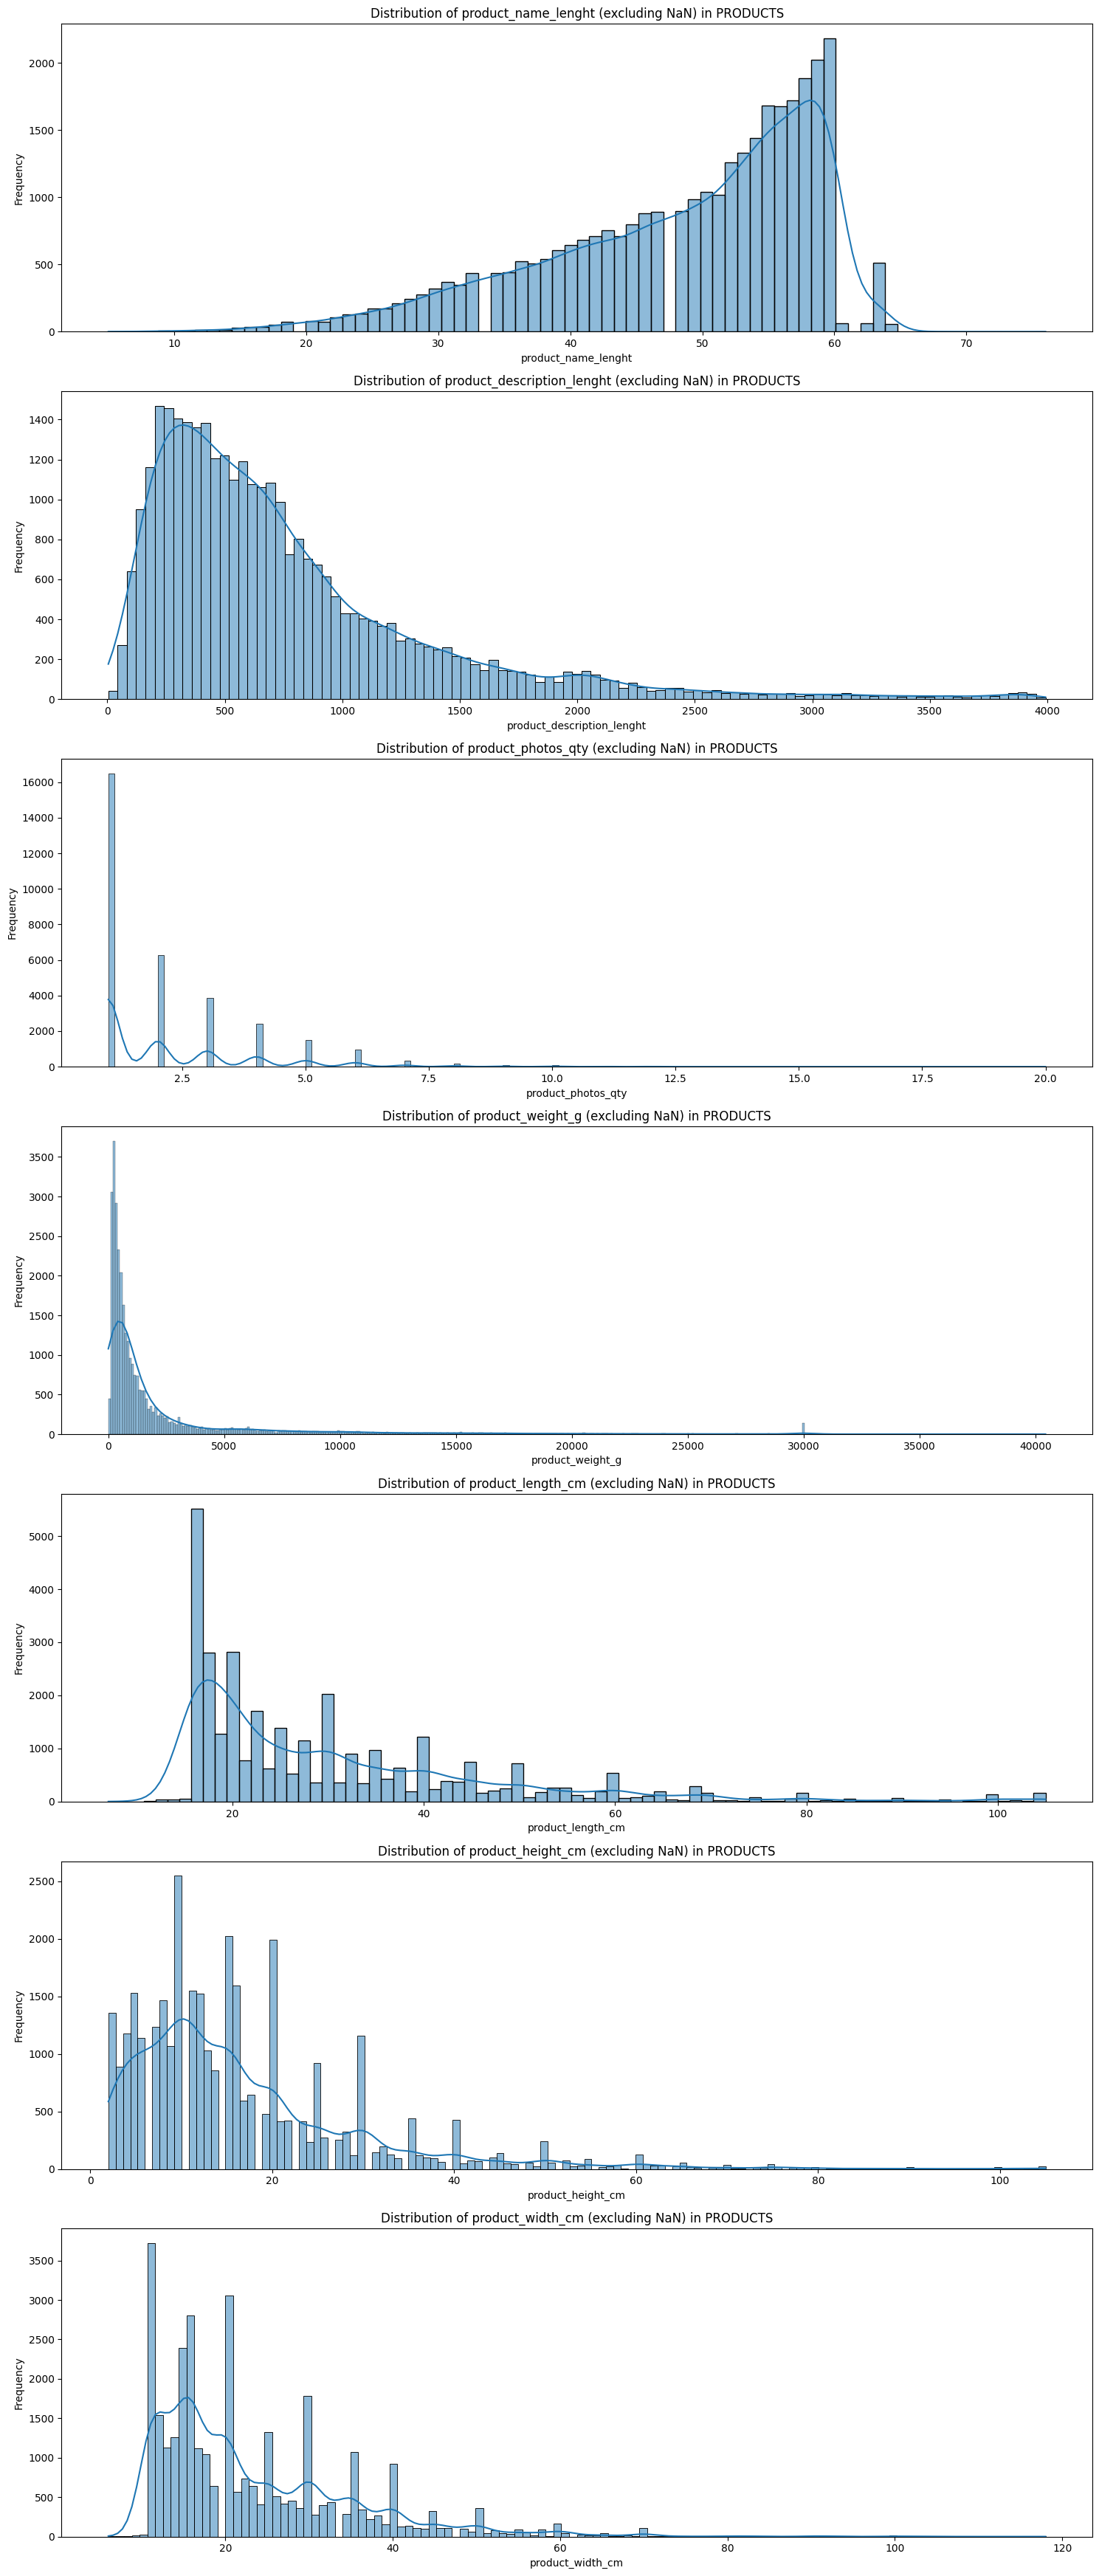


Distribution plots for numerical columns with missing values in REVIEWS DataFrame
No numerical columns with missing values found in REVIEWS DataFrame to plot.

Distribution plots for numerical columns with missing values in CATEGORY_TRANSLATION DataFrame
No numerical columns with missing values found in CATEGORY_TRANSLATION DataFrame to plot.

Distribution plots for numerical columns with missing values in GEOLOACTION DataFrame
No numerical columns with missing values found in GEOLOACTION DataFrame to plot.

Distribution plots for numerical columns with missing values in SELLERS DataFrame
No numerical columns with missing values found in SELLERS DataFrame to plot.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for name, df in dataset.items():
    print(f"\n{'='*80}")
    print(f"Distribution plots for numerical columns with missing values in {name.upper()} DataFrame")
    print(f"{'='*80}")

    current_numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

    numerical_cols_with_missing_in_df = [col for col in current_numerical_cols if df[col].isnull().any()]

    if numerical_cols_with_missing_in_df:
        print(f"Numerical columns with missing values in {name.upper()}: {numerical_cols_with_missing_in_df}")

        num_plots = len(numerical_cols_with_missing_in_df)
        fig, axes = plt.subplots(num_plots, 1, figsize=(15, 5 * num_plots))

        if num_plots == 1:
            axes = [axes]

        for i, col in enumerate(numerical_cols_with_missing_in_df):
            sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
            axes[i].set_title(f'Distribution of {col} (excluding NaN) in {name.upper()}')
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Frequency')
        plt.tight_layout()
        plt.show()
    else:
        print(f"No numerical columns with missing values found in {name.upper()} DataFrame to plot.")

### Impute missing values for numeric column in DataFrame `products`

In [ ]:
print("Imputing missing values DataFrame 'products'...")

products_df = dataset['products']

numerical_cols_with_missing_in_products = [
    'product_name_lenght', 'product_description_lenght', 'product_photos_qty',
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm'
]

for col in numerical_cols_with_missing_in_products:
    if col in products_df.columns:
        median_val = products_df[col].median()
        products_df[col] = products_df[col].fillna(median_val)
        print(f"  Imputing missing values for col '{col}' with median: {median_val}")

dataset['products'] = products_df

print("\nRecheck:")

missing_summary_products = products_df.isnull().sum().sort_values(ascending=False)
missing_percentage_products = (products_df.isnull().sum() / len(products_df) * 100).sort_values(ascending=False)
missing_df_products = pd.concat([missing_summary_products, missing_percentage_products], axis=1, keys=['Missing Count', 'Percentage (%)'])
display(missing_df_products[missing_df_products['Missing Count'] > 0])

print("Missing Value Imputation Completed for DataFrame")

Imputing missing values DataFrame 'products'...
  Imputing missing values for col 'product_name_lenght' with median: 51.0
  Imputing missing values for col 'product_description_lenght' with median: 595.0
  Imputing missing values for col 'product_photos_qty' with median: 1.0
  Imputing missing values for col 'product_weight_g' with median: 700.0
  Imputing missing values for col 'product_length_cm' with median: 25.0
  Imputing missing values for col 'product_height_cm' with median: 13.0
  Imputing missing values for col 'product_width_cm' with median: 20.0

Recheck:


,Missing Count,Percentage (%)
product_category_name,610,1.851234


Missing Value Imputation Completed for DataFrame


### Descriptive Statistics for Categorical Columns

In [ ]:
for name, df in dataset.items():
    category_cols = classified_columns_by_dataframe[name]['category']

    print(f"\n{'='*80}")
    print(f"Descriptive Statistics for Categorical Columns in {name.upper()} DataFrame (excluding '_id' columns)")
    print(f"{'='*80}")

    if category_cols:
        # Filter out columns containing '_id'
        filtered_category_cols = [col for col in category_cols if '_id' not in col]

        if filtered_category_cols:
            display(df[filtered_category_cols].describe())
        else:
            print("--- No Categorical Columns (excluding '_id' columns) Found ---")
    else:
        print("--- No Categorical Columns Found ---")
    print(f"\n{'='*80}")


Descriptive Statistics for Categorical Columns in ORDERS DataFrame (excluding '_id' columns)


,order_status
count,99441
unique,8
top,delivered
freq,96478




Descriptive Statistics for Categorical Columns in CUSTOMERS DataFrame (excluding '_id' columns)


,customer_city,customer_state
count,99441,99441
unique,4119,27
top,sao paulo,SP
freq,15540,41746




Descriptive Statistics for Categorical Columns in ORDER_ITEMS DataFrame (excluding '_id' columns)
--- No Categorical Columns (excluding '_id' columns) Found ---


Descriptive Statistics for Categorical Columns in PAYMENTS DataFrame (excluding '_id' columns)


...

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1




Descriptive Statistics for Categorical Columns in GEOLOACTION DataFrame (excluding '_id' columns)


,geolocation_city,geolocation_state
count,1000163,1000163
unique,8011,27
top,sao paulo,SP
freq,135800,404268




Descriptive Statistics for Categorical Columns in SELLERS DataFrame (excluding '_id' columns)


,seller_city,seller_state
count,3095,3095
unique,611,23
top,sao paulo,SP
freq,694,1849


### Value Counts for Categorical Columns

In [ ]:
for name, df in dataset.items():
    category_cols = classified_columns_by_dataframe[name]['category']

    print(f"\n{'='*80}")
    print(f"Value Counts (including NaN) for Categorical Columns in {name.upper()} DataFrame (excluding '_id' columns)")
    print(f"{'='*80}")

    if category_cols:
        # Filter out columns containing '_id'
        filtered_category_cols = [col for col in category_cols if '_id' not in col]

        if filtered_category_cols:
            for col in filtered_category_cols:
                print(f"\n--- Column: {col} ---")
                display(df[col].value_counts(dropna=False))
        else:
            print("--- No Categorical Columns (excluding '_id' columns) Found ---")
    else:
        print("--- No Categorical Columns Found ---")
    print(f"\n{'='*80}")


Value Counts (including NaN) for Categorical Columns in ORDERS DataFrame (excluding '_id' columns)

--- Column: order_status ---


,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2




Value Counts (including NaN) for Categorical Columns in CUSTOMERS DataFrame (excluding '_id' columns)

--- Column: customer_city ---


,count
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
...,...
olhos d'agua,1
pacotuba,1
sao sebastiao do paraiba,1



--- Column: customer_state ---


...

,count
geolocation_state,
SP,404268
MG,126336
RJ,121169
RS,61851
PR,57859
SC,38328
BA,36045
GO,20139
ES,16748




Value Counts (including NaN) for Categorical Columns in SELLERS DataFrame (excluding '_id' columns)

--- Column: seller_city ---


,count
seller_city,
sao paulo,694
curitiba,127
rio de janeiro,96
belo horizonte,68
ribeirao preto,52
...,...
ipua,1
muqui,1
timoteo,1



--- Column: seller_state ---


,count
seller_state,
SP,1849
PR,349
MG,244
SC,190
RJ,171
RS,129
GO,40
DF,30
ES,23


### Missing Values in Categorical Columns (excluding '_id' columns)

In [ ]:
for name, df in dataset.items():
    category_cols = classified_columns_by_dataframe[name]['category']

    print(f"\n{'='*80}")
    print(f"Missing Values for Categorical Columns in {name.upper()} DataFrame (excluding '_id' columns)")
    print(f"{'='*80}")

    if category_cols:
        # Filter out columns containing '_id'
        filtered_category_cols = [col for col in category_cols if '_id' not in col]

        if filtered_category_cols:
            # Filter the DataFrame to only filtered categorical columns and check for missing values
            missing_categorical = df[filtered_category_cols].isnull().sum()
            missing_categorical_percentage = (df[filtered_category_cols].isnull().sum() / len(df) * 100)

            # Combine into a summary table, showing only columns with actual missing values
            missing_categorical_df = pd.concat([missing_categorical, missing_categorical_percentage], axis=1, keys=['Missing Count', 'Percentage (%)'])
            display(missing_categorical_df[missing_categorical_df['Missing Count'] > 0])
        else:
            print("--- No Categorical Columns (excluding '_id' columns) Found ---")
    else:
        print("--- No Categorical Columns Found ---")
    print(f"\n{'='*80}")


Missing Values for Categorical Columns in ORDERS DataFrame (excluding '_id' columns)


,Missing Count,Percentage (%)




Missing Values for Categorical Columns in CUSTOMERS DataFrame (excluding '_id' columns)


,Missing Count,Percentage (%)




Missing Values for Categorical Columns in ORDER_ITEMS DataFrame (excluding '_id' columns)
--- No Categorical Columns (excluding '_id' columns) Found ---


Missing Values for Categorical Columns in PAYMENTS DataFrame (excluding '_id' columns)


...

,Missing Count,Percentage (%)




Missing Values for Categorical Columns in GEOLOACTION DataFrame (excluding '_id' columns)


,Missing Count,Percentage (%)




Missing Values for Categorical Columns in SELLERS DataFrame (excluding '_id' columns)


,Missing Count,Percentage (%)


In [ ]:
print("Imputing missing values for categorical columns in 'products' and 'reviews' DataFrames...")

# Impute 'product_category_name' in 'products' with 'unknown'
products_df = dataset['products']
if 'product_category_name' in products_df.columns:
    products_df['product_category_name'] = products_df['product_category_name'].fillna('unknown')
    print("  Missing values in 'product_category_name' column of products_df filled with 'unknown'")
dataset['products'] = products_df

# Impute 'review_comment_title' and 'review_comment_message' in 'reviews' with 'no comment'
reviews_df = dataset['reviews']
if 'review_comment_title' in reviews_df.columns:
    reviews_df['review_comment_title'] = reviews_df['review_comment_title'].fillna('no comment')
    print("  Missing values in 'review_comment_title' column of reviews_df filled with 'no comment'")
if 'review_comment_message' in reviews_df.columns:
    reviews_df['review_comment_message'] = reviews_df['review_comment_message'].fillna('no comment')
    print("  Missing values in 'review_comment_message' column of reviews_df filled with 'no comment'")
dataset['reviews'] = reviews_df

print("\nChecking missing values after imputation for 'products' DataFrame:")
missing_summary_products_cat = products_df.isnull().sum().sort_values(ascending=False)
missing_percentage_products_cat = (products_df.isnull().sum() / len(products_df) * 100).sort_values(ascending=False)
missing_df_products_cat = pd.concat([missing_summary_products_cat, missing_percentage_products_cat], axis=1, keys=['Missing Count', 'Percentage (%)'])
display(missing_df_products_cat[missing_df_products_cat['Missing Count'] > 0])

print("\nChecking missing values after imputation for 'reviews' DataFrame:")
missing_summary_reviews_cat = reviews_df.isnull().sum().sort_values(ascending=False)
missing_percentage_reviews_cat = (reviews_df.isnull().sum() / len(reviews_df) * 100).sort_values(ascending=False)
missing_df_reviews_cat = pd.concat([missing_summary_reviews_cat, missing_percentage_reviews_cat], axis=1, keys=['Missing Count', 'Percentage (%)'])
display(missing_df_reviews_cat[missing_df_reviews_cat['Missing Count'] > 0])

print("Missing value imputation for categorical columns completed.")

Imputing missing values for categorical columns in 'products' and 'reviews' DataFrames...
  Missing values in 'product_category_name' column of products_df filled with 'unknown'
  Missing values in 'review_comment_title' column of reviews_df filled with 'no comment'
  Missing values in 'review_comment_message' column of reviews_df filled with 'no comment'

Checking missing values after imputation for 'products' DataFrame:


,Missing Count,Percentage (%)



Checking missing values after imputation for 'reviews' DataFrame:


,Missing Count,Percentage (%)


Missing value imputation for categorical columns completed.


### Descriptive Statistics for Datetime Columns

In [ ]:
for name, df in dataset.items():
    datetime_cols = classified_columns_by_dataframe[name]['datetime']

    print(f"\n{'='*80}")
    print(f"Descriptive Statistics for Datetime Columns in {name.upper()} DataFrame")
    print(f"{'='*80}")

    if datetime_cols:
        display(df[datetime_cols].describe())
    else:
        print("--- No Datetime Columns Found ---")
    print(f"\n{'='*80}")


Descriptive Statistics for Datetime Columns in ORDERS DataFrame


,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99281,97658,96476,99441
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00




Descriptive Statistics for Datetime Columns in CUSTOMERS DataFrame
--- No Datetime Columns Found ---


Descriptive Statistics for Datetime Columns in ORDER_ITEMS DataFrame


,shipping_limit_date
count,112650
mean,2018-01-07 15:36:52.192685312
min,2016-09-19 00:15:34
25%,2017-09-20 20:57:27.500000
50%,2018-01-26 13:59:35
75%,2018-05-10 14:34:00.750000128
max,2020-04-09 22:35:08




Descriptive Statistics for Datetime Columns in PAYMENTS DataFrame
--- No Datetime Columns Found ---


Descriptive Statistics for Datetime Columns in PRODUCTS DataFrame
--- No Datetime Columns Found ---


Descriptive Statistics for Datetime Columns in REVIEWS DataFrame


,review_creation_date,review_answer_timestamp
count,99224,99224
mean,2018-01-12 20:49:23.948238336,2018-01-16 00:23:56.977938688
min,2016-10-02 00:00:00,2016-10-07 18:32:28
25%,2017-09-23 00:00:00,2017-09-27 01:53:27.249999872
50%,2018-02-02 00:00:00,2018-02-04 22:41:47.500000
75%,2018-05-16 00:00:00,2018-05-20 12:11:21.500000
max,2018-08-31 00:00:00,2018-10-29 12:27:35




Descriptive Statistics for Datetime Columns in CATEGORY_TRANSLATION DataFrame
--- No Datetime Columns Found ---


Descriptive Statistics for Datetime Columns in GEOLOACTION DataFrame
--- No Datetime Columns Found ---


Descriptive Statistics for Datetime Columns in SELLERS DataFrame
--- No Datetime Columns Found ---



### Missing Values in Datetime Columns

In [ ]:
for name, df in dataset.items():
    datetime_cols = classified_columns_by_dataframe[name]['datetime']

    print(f"\n{'='*80}")
    print(f"Missing Values for Datetime Columns in {name.upper()} DataFrame")
    print(f"{'='*80}")

    if datetime_cols:
        # Filter the DataFrame to only datetime columns and check for missing values
        missing_datetime = df[datetime_cols].isnull().sum()
        missing_datetime_percentage = (df[datetime_cols].isnull().sum() / len(df) * 100)

        # Combine into a summary table, showing only columns with actual missing values
        missing_datetime_df = pd.concat([missing_datetime, missing_datetime_percentage], axis=1, keys=['Missing Count', 'Percentage (%)'])
        display(missing_datetime_df[missing_datetime_df['Missing Count'] > 0])
    else:
        print("--- No Datetime Columns Found ---")
    print(f"\n{'='*80}")


Missing Values for Datetime Columns in ORDERS DataFrame


,Missing Count,Percentage (%)
order_approved_at,160,0.160899
order_delivered_carrier_date,1783,1.793023
order_delivered_customer_date,2965,2.981668




Missing Values for Datetime Columns in CUSTOMERS DataFrame
--- No Datetime Columns Found ---


Missing Values for Datetime Columns in ORDER_ITEMS DataFrame


,Missing Count,Percentage (%)




Missing Values for Datetime Columns in PAYMENTS DataFrame
--- No Datetime Columns Found ---


Missing Values for Datetime Columns in PRODUCTS DataFrame
--- No Datetime Columns Found ---


Missing Values for Datetime Columns in REVIEWS DataFrame


,Missing Count,Percentage (%)




Missing Values for Datetime Columns in CATEGORY_TRANSLATION DataFrame
--- No Datetime Columns Found ---


Missing Values for Datetime Columns in GEOLOACTION DataFrame
--- No Datetime Columns Found ---


Missing Values for Datetime Columns in SELLERS DataFrame
--- No Datetime Columns Found ---



In [ ]:
# Get 'orders' DataFrame
orders_df = dataset['orders']

# Get the list of datetime columns from classification
datetime_cols_orders = classified_columns_by_dataframe['orders']['datetime']

# Filter rows with missing values in datetime columns
missing_rows_orders = orders_df[orders_df[datetime_cols_orders].isnull().any(axis=1)]

print(f"Displaying rows with missing values in datetime columns of 'orders' DataFrame ({len(missing_rows_orders)} rows):")
display(missing_rows_orders)

Displaying rows with missing values in datetime columns of 'orders' DataFrame (2980 rows):


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaT,2018-06-28
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaT,NaT,2017-10-03
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaT,2018-02-07
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaT,NaT,NaT,2018-10-01
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaT,NaT,2018-02-06
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaT,NaT,NaT,2018-09-27
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaT,NaT,2017-09-15


Missing values in the datetime columns were not imputed because they are consistent with the corresponding order status and represent meaningful business information.

In [ ]:
orders.groupby("order_status")[
    "order_delivered_customer_date"
].apply(lambda x: x.isna().sum())

,order_delivered_customer_date
order_status,
approved,2
canceled,619
created,5
delivered,8
invoiced,314
processing,301
shipped,1107
unavailable,609


There are 8 orders with a delivered status but missing order_delivered_customer_date. These records are considered data quality issues and will be excluded from analyses that require delivery date information.

## Final Dataset Validation & Comparison
This section provides a summary of the cleaned dataset to verify that data types are correct and missing values have been handled according to the previous steps.

In [ ]:
print("=== FINAL DATASET VALIDATION REPORT ===\n")

for name, df in dataset.items():
    print(f"--- {name.upper()} DataFrame ---")
    print(f"Total Rows: {len(df)}")

    # Check for missing values
    missing = df.isnull().sum()
    total_missing = missing.sum()

    # Summary of columns with missing values (if any)
    if total_missing > 0:
        print("Missing Values detected:")
        display(missing[missing > 0])
    else:
        print("No missing values found.")

    # Display Data Types for verification
    print("\nData Types:")
    display(df.dtypes.to_frame(name='Data Type'))
    print("\n" + "="*40 + "\n")

print("Validation Complete.")

=== FINAL DATASET VALIDATION REPORT ===

--- ORDERS DataFrame ---
Total Rows: 99441
Missing Values detected:


,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965



Data Types:


,Data Type
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]




--- CUSTOMERS DataFrame ---
Total Rows: 99441
No missing values found.

Data Types:


...



--- GEOLOACTION DataFrame ---
Total Rows: 1000163
No missing values found.

Data Types:


,Data Type
geolocation_zip_code_prefix,int64
geolocation_lat,float64
geolocation_lng,float64
geolocation_city,object
geolocation_state,object




--- SELLERS DataFrame ---
Total Rows: 3095
No missing values found.

Data Types:


,Data Type
seller_id,object
seller_zip_code_prefix,int64
seller_city,object
seller_state,object




Validation Complete.


In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define the target directory
export_path = '/content/drive/MyDrive/Colab Notebooks/OlistProject/Cleaned_dataset'

# Create the directory if it doesn't exist
if not os.path.exists(export_path):
    os.makedirs(export_path)
    print(f"Created directory: {export_path}")
else:
    print(f"Directory already exists: {export_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Created directory: /content/drive/MyDrive/Colab Notebooks/OlistProject/Cleaned_dataset


In [ ]:
print(f"Exporting cleaned files to {export_path}:")
for name, df in dataset.items():
    filename = os.path.join(export_path, f"{name}.pkl")
    df.to_pickle(filename)
    print(f" - Saved: {filename}")

print("\nAll files exported to Google Drive successfully.")

Exporting cleaned files to /content/drive/MyDrive/Colab Notebooks/OlistProject/Cleaned_dataset:
 - Saved: /content/drive/MyDrive/Colab Notebooks/OlistProject/Cleaned_dataset/orders.pkl
 - Saved: /content/drive/MyDrive/Colab Notebooks/OlistProject/Cleaned_dataset/customers.pkl
 - Saved: /content/drive/MyDrive/Colab Notebooks/OlistProject/Cleaned_dataset/order_items.pkl
 - Saved: /content/drive/MyDrive/Colab Notebooks/OlistProject/Cleaned_dataset/payments.pkl
 - Saved: /content/drive/MyDrive/Colab Notebooks/OlistProject/Cleaned_dataset/products.pkl
 - Saved: /content/drive/MyDrive/Colab Notebooks/OlistProject/Cleaned_dataset/reviews.pkl
 - Saved: /content/drive/MyDrive/Colab Notebooks/OlistProject/Cleaned_dataset/category_translation.pkl
 - Saved: /content/drive/MyDrive/Colab Notebooks/OlistProject/Cleaned_dataset/geoloaction.pkl
 - Saved: /content/drive/MyDrive/Colab Notebooks/OlistProject/Cleaned_dataset/sellers.pkl

All files exported to Google Drive successfully.


In [ ]:
import os

# Create a directory for cleaned data if needed, or just save to /content
print("Exporting cleaned files:")
for name, df in dataset.items():
    filename = f"{name}.pkl"
    df.to_pickle(filename)
    print(f" - Saved: {filename}")

print("\nAll files exported successfully.")

Exporting cleaned files:
 - Saved: orders.pkl
 - Saved: customers.pkl
 - Saved: order_items.pkl
 - Saved: payments.pkl
 - Saved: products.pkl
 - Saved: reviews.pkl
 - Saved: category_translation.pkl
 - Saved: geoloaction.pkl
 - Saved: sellers.pkl

All files exported successfully.


In [ ]:
from google.colab import files

files_to_download = [
    'orders.pkl', 'customers.pkl', 'order_items.pkl',
    'payments.pkl', 'products.pkl', 'reviews.pkl',
    'category_translation.pkl', 'geoloaction.pkl', 'sellers.pkl'
]

print("Triggering downloads...")
for filename in files_to_download:
    if os.path.exists(filename):
        files.download(filename)
    else:
        print(f"Warning: {filename} not found.")

Triggering downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#EDA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

data_path = '/content/drive/MyDrive/Colab Notebooks/OlistProject/Cleaned_dataset'

if os.path.exists(data_path):
    print(f"Contents of '{data_path}':")
    for item in os.listdir(data_path):
        print(item)
else:
    print(f"The directory '{data_path}' does not exist. Please check the path.")

Mounted at /content/drive
Contents of '/content/drive/MyDrive/Colab Notebooks/OlistProject/Cleaned_dataset':
orders.pkl
customers.pkl
order_items.pkl
payments.pkl
products.pkl
reviews.pkl
category_translation.pkl
geoloaction.pkl
sellers.pkl


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
orders = pd.read_pickle(os.path.join(data_path, 'orders.pkl'))
customers = pd.read_pickle(os.path.join(data_path, 'customers.pkl'))
order_items = pd.read_pickle(os.path.join(data_path, 'order_items.pkl'))
payments = pd.read_pickle(os.path.join(data_path, 'payments.pkl'))
products = pd.read_pickle(os.path.join(data_path, 'products.pkl'))
reviews = pd.read_pickle(os.path.join(data_path, 'reviews.pkl'))
sellers = pd.read_pickle(os.path.join(data_path, 'sellers.pkl'))
category_translation = pd.read_pickle(os.path.join(data_path, 'category_translation.pkl'))
geolocation = pd.read_pickle(os.path.join(data_path, 'geoloaction.pkl'))

print("Đã tải tất cả các tệp dữ liệu thành công!")

Đã tải tất cả các tệp dữ liệu thành công!


In [ ]:
marketplace_scale = pd.DataFrame({
    "Metric":[
        "Total Orders",
        "Total Customers",
        "Total Sellers",
        "Total Products",
        "Total Categories"
    ],
    "Value":[
        orders["order_id"].nunique(),
        customers["customer_unique_id"].nunique(),
        sellers["seller_id"].nunique(),
        products["product_id"].nunique(),
        products["product_category_name"].nunique()
    ]
})

marketplace_scale["Value"] = marketplace_scale["Value"].map("{:,}".format)

marketplace_scale

,Metric,Value
0,Total Orders,"99,441"
1,Total Customers,"96,096"
2,Total Sellers,"3,095"
3,Total Products,"32,951"
4,Total Categories,74


/tmp/ipykernel_11236/607625107.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reviews, x='review_score', palette='viridis')


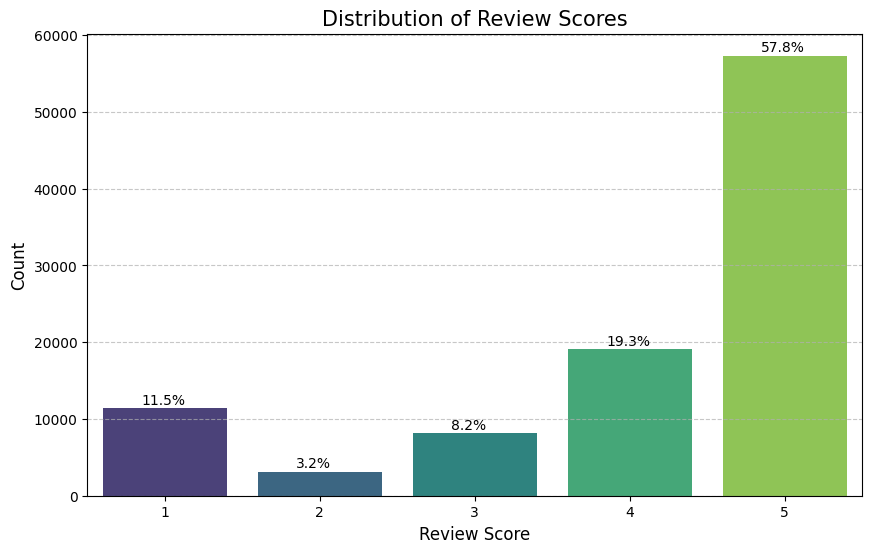

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=reviews, x='review_score', palette='viridis')

plt.title('Distribution of Review Scores', fontsize=15)
plt.xlabel('Review Score', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

total = len(reviews)
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.15
    y = p.get_height() + 500
    plt.annotate(percentage, (x, y), fontsize=10)

plt.show()

/tmp/ipykernel_11236/1098216286.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=payments, x='payment_type', palette='viridis', order=payments['payment_type'].value_counts().index)


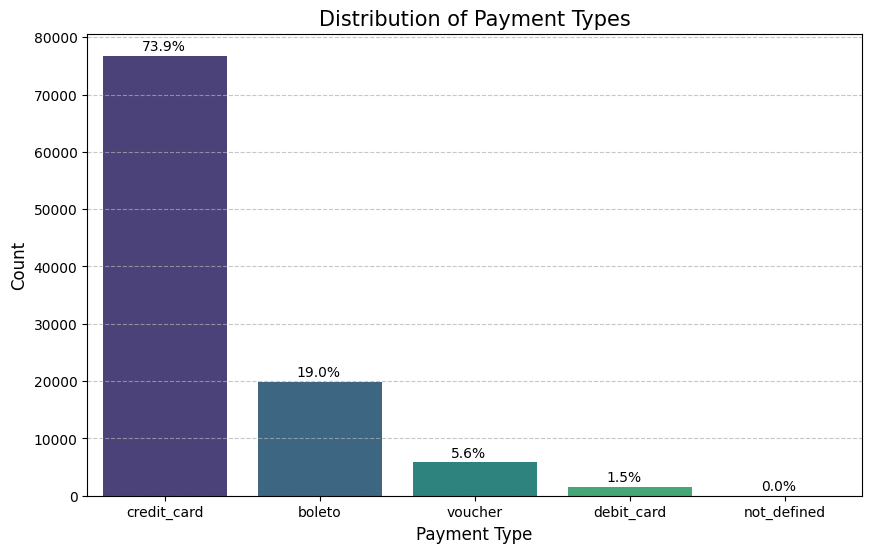

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=payments, x='payment_type', palette='viridis', order=payments['payment_type'].value_counts().index)

plt.title('Distribution of Payment Types', fontsize=15)
plt.xlabel('Payment Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

total_payments = len(payments)
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_payments)
    x = p.get_x() + p.get_width() / 2 - 0.15
    y = p.get_height() + 1000
    plt.annotate(percentage, (x, y), fontsize=10)

plt.show()

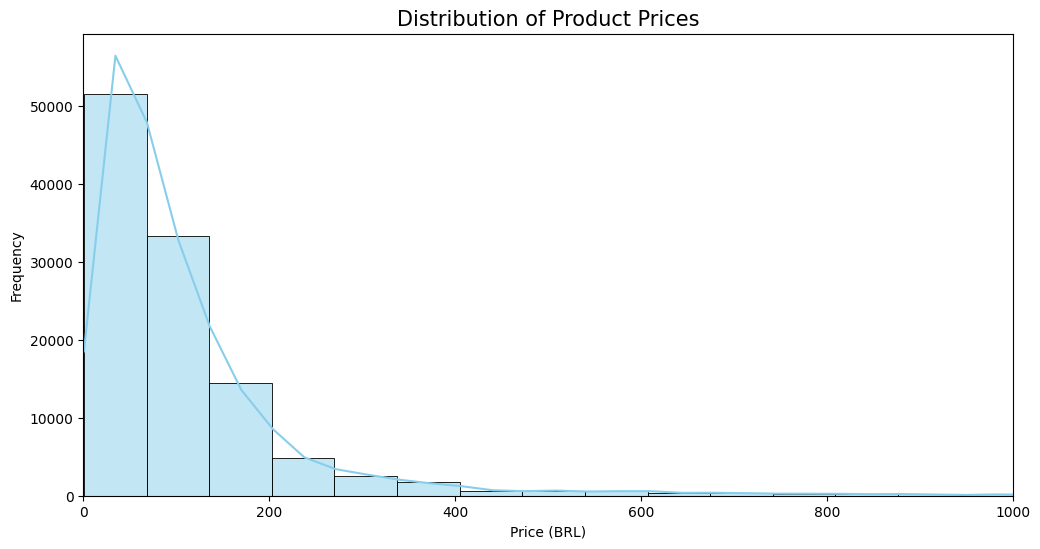

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(order_items['price'], bins=100, kde=True, color='skyblue')
plt.title('Distribution of Product Prices', fontsize=15)
plt.xlabel('Price (BRL)')
plt.ylabel('Frequency')
plt.xlim(0, 1000)
plt.show()

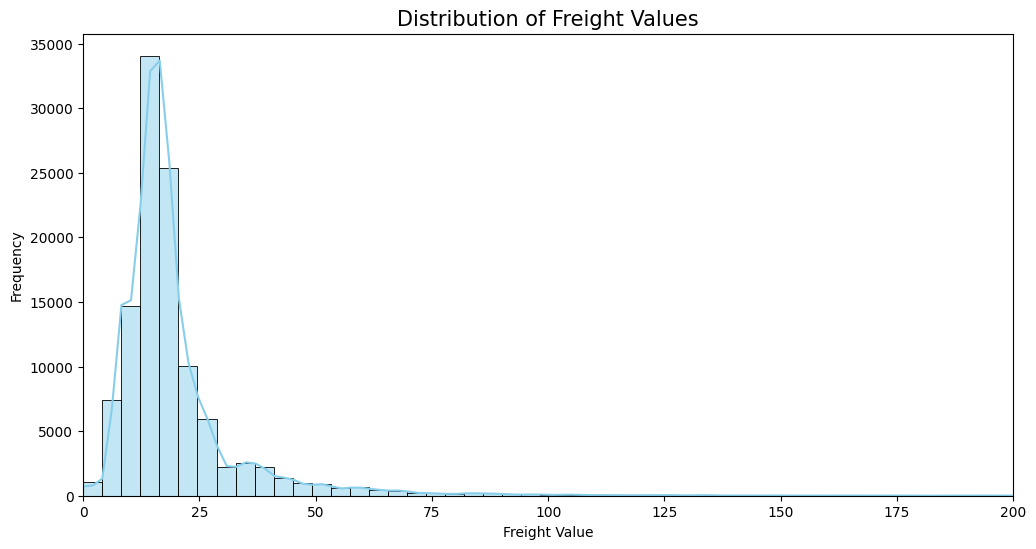

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(order_items['freight_value'], bins=100, kde=True, color='skyblue')
plt.title('Distribution of Freight Values', fontsize=15)
plt.xlabel('Freight Value')
plt.ylabel('Frequency')
plt.xlim(0, 200)
plt.show()

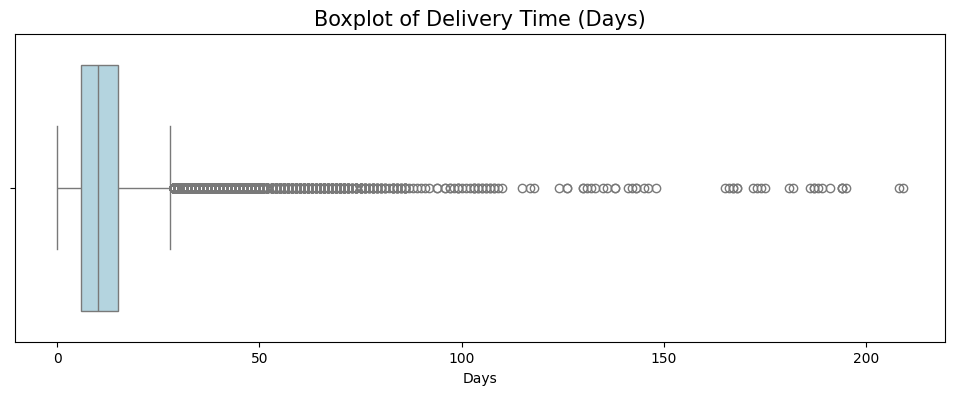

In [ ]:
orders['delivery_time'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

plt.figure(figsize=(12, 4))
sns.boxplot(x=orders['delivery_time'].dropna(), color='lightblue')
plt.title('Boxplot of Delivery Time (Days)', fontsize=15)
plt.xlabel('Days')
plt.show()

/tmp/ipykernel_11236/2307318185.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_english, x='count', y='product_category_name_english', palette='coolwarm')


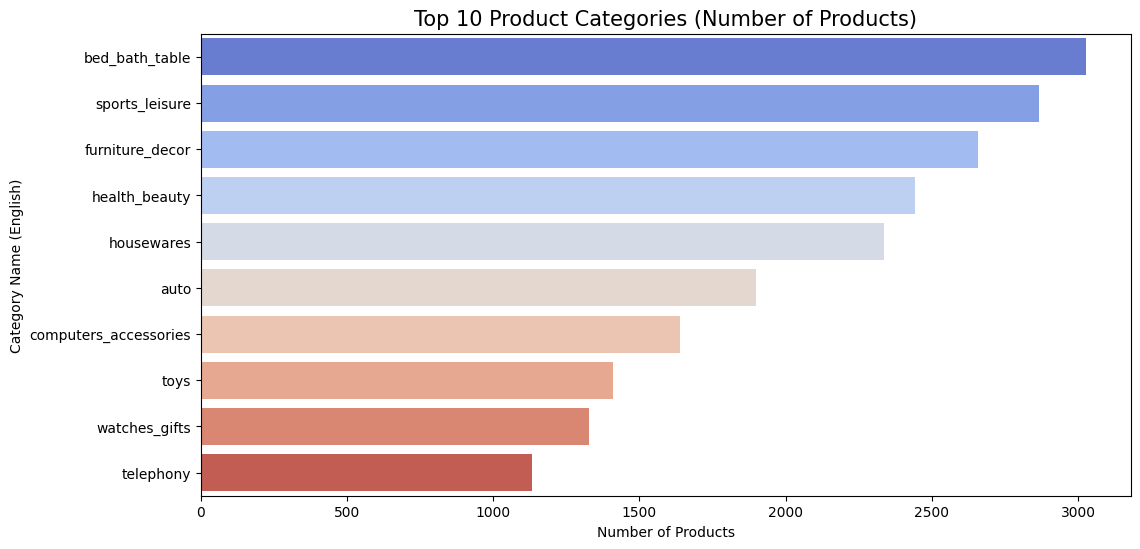

In [ ]:
products_translated = products.merge(category_translation, on='product_category_name', how='left')

top_10_english = (
    products_translated['product_category_name_english']
    .value_counts()
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_english, x='count', y='product_category_name_english', palette='coolwarm')

plt.title('Top 10 Product Categories (Number of Products)', fontsize=15)
plt.xlabel('Number of Products')
plt.ylabel('Category Name (English)')
plt.show()

/tmp/ipykernel_11236/3030740654.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_reviewed.sort_values('avg_score', ascending=False),


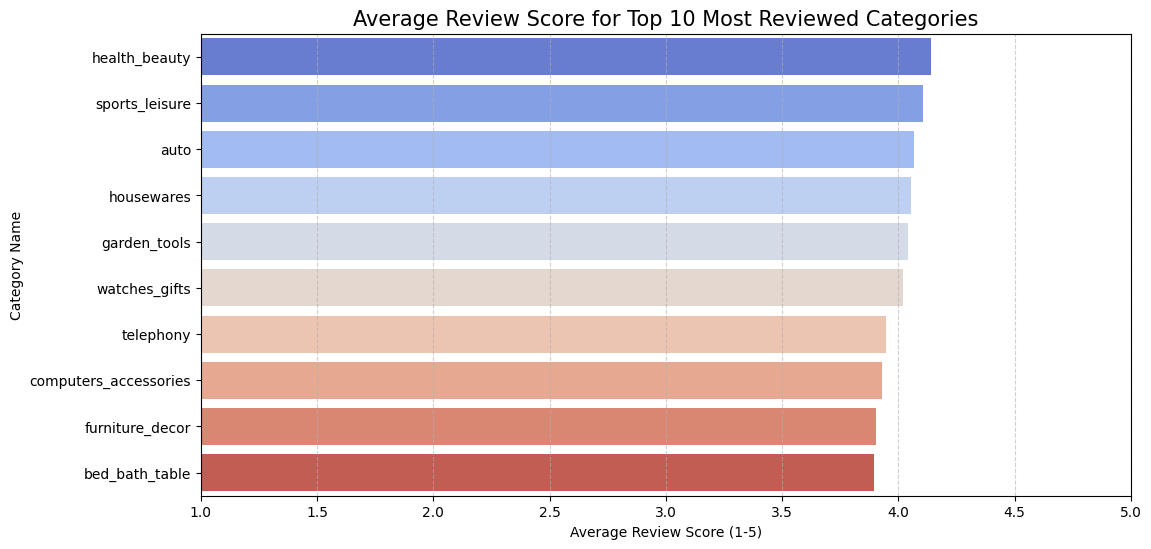

In [ ]:
# order_items links orders to products, reviews links orders to scores
review_category_data = (
    reviews[['order_id', 'review_score']]
    .merge(order_items[['order_id', 'product_id']], on='order_id')
    .merge(products_translated[['product_id', 'product_category_name_english']], on='product_id')
)

# Calculate mean review score per category
category_review_stats = (
    review_category_data.groupby('product_category_name_english')
    .agg(avg_score=('review_score', 'mean'), review_count=('review_score', 'count'))
    .reset_index()
)

# Filtering for the top 10 categories by number of reviews to ensure statistical relevance
top_10_reviewed = category_review_stats.sort_values(by='review_count', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_reviewed.sort_values('avg_score', ascending=False),
            x='avg_score', y='product_category_name_english', palette='coolwarm')

plt.title('Average Review Score for Top 10 Most Reviewed Categories', fontsize=15)
plt.xlabel('Average Review Score (1-5)')
plt.ylabel('Category Name')
plt.xlim(1, 5)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

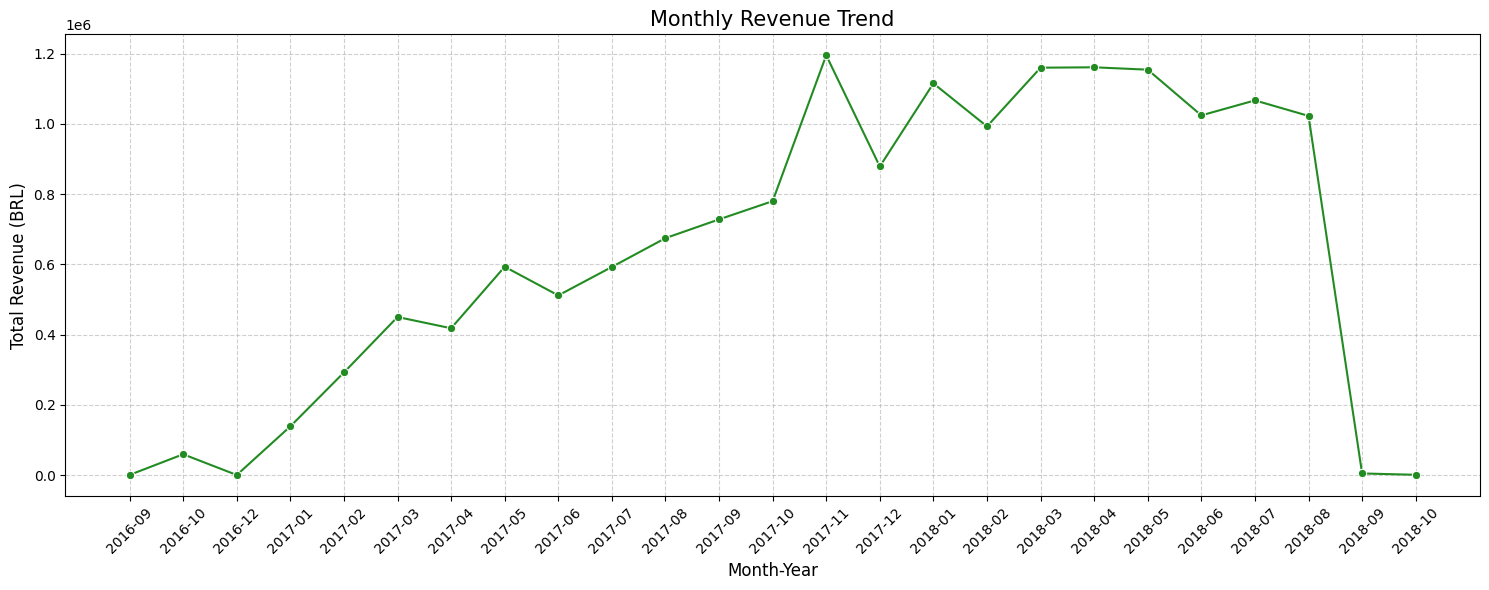

In [ ]:
revenue_data = orders[['order_id', 'order_purchase_timestamp']].merge(
    payments[['order_id', 'payment_value']], on='order_id'
)

# Create a Month-Year column
revenue_data['month_year'] = revenue_data['order_purchase_timestamp'].dt.to_period('M')

# Aggregate revenue by month
monthly_revenue = revenue_data.groupby('month_year')['payment_value'].sum().reset_index()
monthly_revenue['month_year_str'] = monthly_revenue['month_year'].astype(str)

# Plotting
plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_revenue, x='month_year_str', y='payment_value', marker='o', color='forestgreen')

plt.title('Monthly Revenue Trend', fontsize=15)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Total Revenue (BRL)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

/tmp/ipykernel_11236/1818234659.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_counts, x='state', y='order_count', palette='viridis')


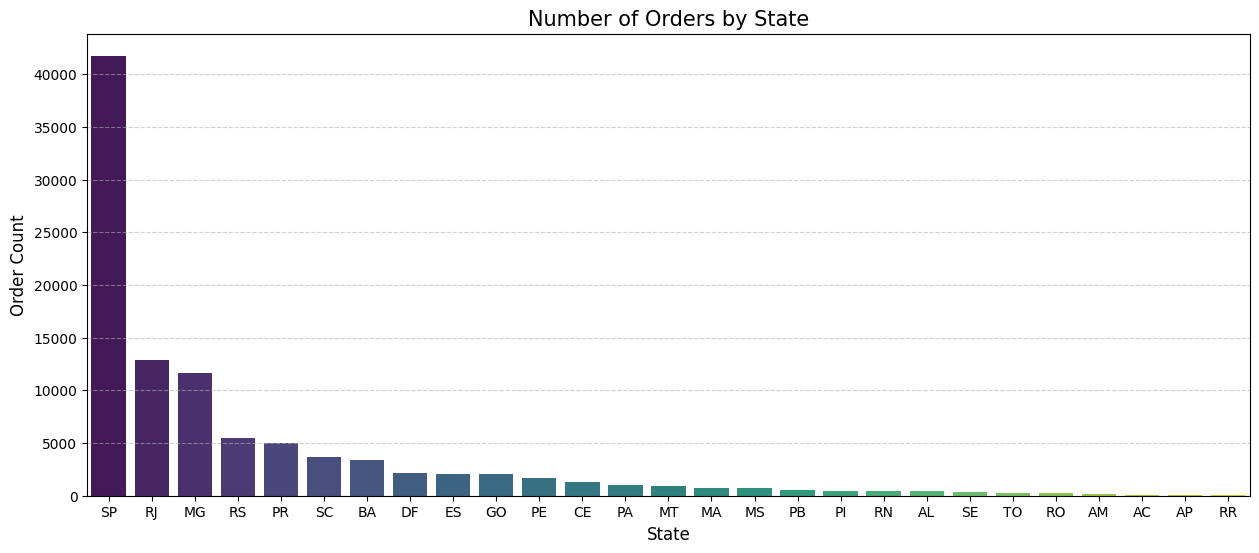

In [ ]:
orders_by_state = orders.merge(customers[['customer_id', 'customer_state']], on='customer_id')

# Count orders per state
state_counts = orders_by_state['customer_state'].value_counts().reset_index()
state_counts.columns = ['state', 'order_count']

# Plotting
plt.figure(figsize=(15, 6))
sns.barplot(data=state_counts, x='state', y='order_count', palette='viridis')

plt.title('Number of Orders by State', fontsize=15)
plt.xlabel('State', fontsize=12)
plt.ylabel('Order Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

/tmp/ipykernel_11236/1271579817.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_payment_value, x='payment_type', y='payment_value', palette='viridis')


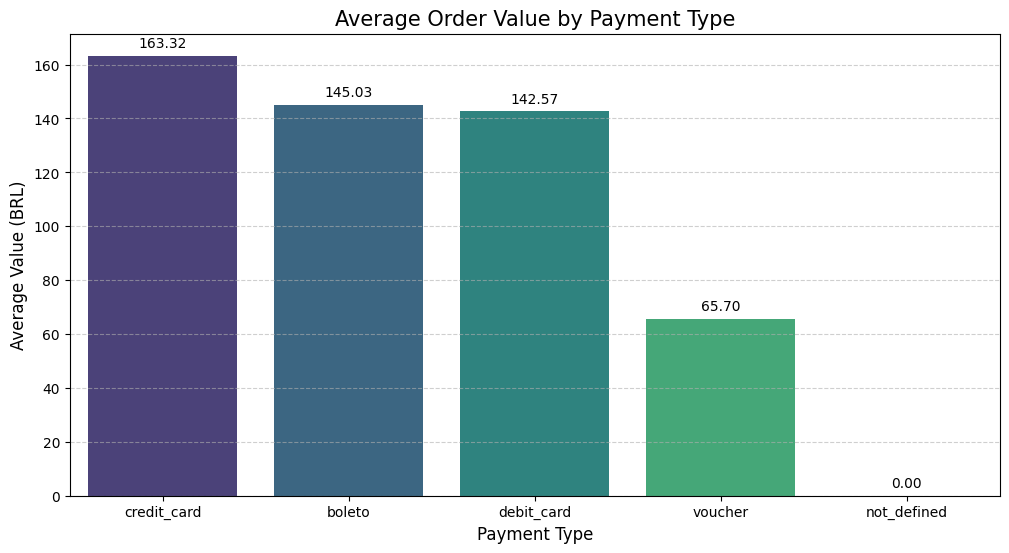

In [ ]:
# Calculate average payment value per payment type
avg_payment_value = payments.groupby('payment_type')['payment_value'].mean().sort_values(ascending=False).reset_index()

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_payment_value, x='payment_type', y='payment_value', palette='viridis')

plt.title('Average Order Value by Payment Type', fontsize=15)
plt.xlabel('Payment Type', fontsize=12)
plt.ylabel('Average Value (BRL)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add labels on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.show()

# Marketplace Overview Analysis

## 1. Business Scale
The Olist marketplace operates at a significant scale, managing over **99,000 orders** and serving approximately **96,000 unique customers**. The ecosystem is supported by over **3,000 sellers** offering a diverse catalog of **32,000+ unique products** across **74 categories**.

## 2. Customer Satisfaction (Review Scores)
Overall customer satisfaction is high, with approximately **57.8%** of reviews giving a perfect **5-star rating**. However, there is a notable **11.5%** of 1-star reviews, indicating specific areas for service improvement. On average, categories like 'Health & Beauty' and 'Sports & Leisure' maintain strong positive feedback.

## 3. Payment Preferences
Brazilian consumers heavily prefer **Credit Cards**, which account for **73.9%** of all transactions. Interestingly, Credit Card transactions also boast the highest average order value (~163 BRL), followed by 'Boleto' and 'Debit Cards'.

## 4. Sales and Logistics
- **Pricing:** Most products are affordable, with prices largely concentrated under **200 BRL**.
- **Logistics:** The median delivery time is around **10-12 days**, though the boxplot analysis reveals several outliers where delivery took significantly longer (up to 200 days), suggesting geographical or logistical challenges in certain regions.
- **Geography:** The **Sao Paulo (SP)** state is the primary hub of activity, generating significantly more orders than any other state, followed by Rio de Janeiro (RJ) and Minas Gerais (MG).

## 5. Revenue Trends
The monthly revenue showed a consistent **upward trend throughout 2017**, peaking towards the end of the year. There is a sharp decline observed in late 2018, which likely indicates the end of the dataset's collection period rather than a business collapse.

## 6. Top Categories
Categories like **Bed Bath Table**, **Health Beauty**, and **Sports Leisure** are the most dominant in terms of both product variety and review volume, representing the core pillars of the marketplace's inventory.

In [7]:
pip install sqlalchemy

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------- ----- 1.8/2.1 MB 8.0 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 8.0 MB/s  0:00:00

   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
pip install sqlalchemy pyodbc

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:

import pandas as pd
from sqlalchemy import create_engine

SERVER = r"DESKTOP-S44F4NG\SQLEXPRESS"
DATABASE = "Olist raw"

engine = create_engine(
    f"mssql+pyodbc://@{SERVER}/{DATABASE}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

df = pd.read_sql(
    "SELECT customer_id FROM customers",
    engine
)

print(df)

Empty DataFrame
Columns: [customer_id]
Index: []


In [21]:
import os
import pandas as pd

# Folder chứa các file pkl
DATA_PATH = r"D:\HHCDH\OlistProject\Cleaned Dataset"    # <-- sửa lại

# Mapping file -> table
TABLES = {
    # Independent tables (không phụ thuộc bảng nào)
    "customers.pkl": "customers",
    "sellers.pkl": "sellers",
    "products.pkl": "products",
    "category_translation.pkl": "category_translation",
    "geoloaction.pkl": "geolocation",

    # Phụ thuộc customers
    "orders.pkl": "orders",

    # Phụ thuộc orders
    "payments.pkl": "payments",
    "reviews.pkl": "reviews",

    # Phụ thuộc orders + products + sellers
    "order_items.pkl": "order_items",
}

for file_name, table_name in TABLES.items():

    print(f"\n========== {table_name} ==========")

    file_path = os.path.join(DATA_PATH, file_name)

    df = pd.read_pickle(file_path)

    print(df.columns.tolist())

    try:
        df.to_sql(
            name=table_name,
            con=engine,
            if_exists="append",
            index=False
        )

        print(f"✓ Imported {table_name}")

    except Exception as e:
        print(f"❌ Error importing {table_name}")
        print(e)
        break


========== customers ==========
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
✓ Imported customers

========== sellers ==========
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']
✓ Imported sellers

========== products ==========
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
✓ Imported products

========== category_translation ==========
['product_category_name', 'product_category_name_english']
✓ Imported category_translation

========== geolocation ==========
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']
✓ Imported geolocation

========== orders ==========
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered

In [13]:
print(df.columns)

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')


In [15]:
df = pd.read_pickle(r"D:\HHCDH\OlistProject\Cleaned Dataset\customers.pkl")

print(df.columns.tolist())

df.iloc[:1].to_sql(
    "customers",
    con=engine,
    if_exists="append",
    index=False
)

['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


1